#**CHAPTER 1.KNN GEOMETRY**
---

##REFERENCE

https://chatgpt.com/share/69a4e8b1-cd7c-8012-8e0b-ea1ee8e88cd4

##0.CONTEXT

*Introduction*

Chapter 1 is the first time ML & AI 101 turns a familiar idea—“similar things should have similar labels”—into a complete, executable learning system that you can inspect from end to end. The model family here is *k-nearest neighbors (KNN)*, a method that looks deceptively simple: to classify a new point, it finds the closest examples in the training set and lets them vote. But that simplicity is exactly why KNN is the right starting point. It forces you to confront the mechanics of learning without hiding behind training frameworks, learned parameters, or abstract optimization stories. In this chapter, the “intelligence” of the model is almost entirely in the *data geometry* and in the *distance metric* you choose. Everything else is bookkeeping: store points, compute distances, take a vote.

The notebook is designed as a mechanics-first laboratory. That means the dataset is synthetic and generated inside the notebook, so you control its structure and know what “ground truth” means. Instead of inheriting complexity from real-world datasets, you create the complexity you want to study. Here, the core structure is two Gaussian clusters in two dimensions. The choice is intentional: two-dimensional data can be visualized directly, so you can literally see the assumption KNN makes. If class 0 points occupy one region of the plane and class 1 points occupy another, then the nearest neighbors of a new point should usually come from the region it lies in. KNN is not learning a rule in the way a neural network does; it is exploiting a geometric regularity you can observe.

This chapter also introduces a key theme that will stay with you throughout the sequence: the difference between *training* and *inference*. In KNN, that distinction is unusually clear. Training is not gradient descent. There is no backpropagation, no parameter updates, and no learned weight matrices. Training is mainly (1) selecting a hyperparameter *k* and (2) storing the training set. The model’s capacity is controlled by k: small k leads to a flexible, locally sensitive classifier that can overfit; large k produces a smoother decision rule that can underfit by washing out local structure. Inference, by contrast, is the moment you take a *new* synthetic point, compute its distances to the stored dataset, find the nearest ones, and output a predicted label. The notebook makes this distinction explicit by (a) treating k-selection as a “training loop” with a validation loss history, and (b) performing a standalone inference demo on a newly generated sample after training decisions have been made.

Visualization is not an accessory here; it is the core instrument. Because the dataset lives in 2D, you can see the class clusters, the spread of noise, and the regions where classes overlap. Later, you visualize the model itself—not by looking at parameters (there are none), but by plotting the *decision boundary* induced by the nearest-neighbor voting rule. This decision boundary is the tangible object you are really studying: it is how KNN partitions the plane into regions that map to class labels. When you change k, you change that partition. When you add noise, you perturb how points sit relative to the boundary. The notebook is built to make those relationships concrete.

Mechanically, the notebook follows a fixed structure that will recur in later chapters, even as the models become more sophisticated. Cell 1 sets up deterministic behavior, device selection, and plotting utilities so every notebook has consistent instrumentation. Cell 2 defines synthetic data generators and normalization routines. Cell 3 creates the dataset, performs train/validation/test splits, normalizes inputs, and visualizes the data structure that the model will exploit. Cell 4 defines the model, including the manual computation of Euclidean distances and the majority vote logic. Cell 5 runs a controlled hyperparameter search over k, printing epoch-like progress and storing a loss curve. Cell 6 evaluates on the test set and visualizes the “training dynamics” of k-selection. Cell 7 demonstrates inference on a truly new sample and visualizes where it lands relative to the learned boundary. Cell 8 applies a stress test by adding increasing amounts of noise to inputs and measuring how accuracy degrades. Cell 9 provides interpretability through a decision-boundary plot. Cell 10 saves artifacts and prints a metrics dictionary that can be referenced by Cell 11’s GPT reflection.

Conceptually, Chapter 1 is about inductive bias in its simplest form. KNN’s inductive bias is not a set of learned parameters. It is the claim that the label function is locally smooth in the chosen feature space: nearby points tend to share labels. That claim is not always true in real problems, and later chapters will introduce models that *learn* representations where it becomes more true. But you cannot appreciate representation learning unless you first understand what it means to rely on a fixed geometry. This chapter therefore teaches you to think like a mechanic: if the model’s behavior is wrong, you ask whether the space is wrong, whether the metric is wrong, whether k is wrong, or whether the data distribution violates the smoothness assumption. That diagnostic mindset is the foundation on which the rest of ML & AI 101 will build.

In short, this notebook’s aim is not to impress you with performance. Its aim is to make the idea of “learning” visible and testable using the simplest possible engine. You will leave this chapter with a concrete understanding of how a classifier can emerge from geometry, how hyperparameters control bias–variance tradeoffs, how training and inference differ even when training is trivial, and how visualization and stress testing reveal what a model is really doing. With that foundation, the course can progress to dense neural networks in Chapter 2, where the geometry itself becomes something the model can shape through learned parameters.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Imports, Determinism, Device, and Plotting Infrastructure**

Cell 1 establishes the shared laboratory infrastructure that every chapter depends on. The goal is not merely to import libraries; it is to create a controlled environment where results are reproducible and plots are standardized. The determinism block seeds Python’s `random`, NumPy, and PyTorch (including all CUDA devices) to ensure that synthetic data generation and any stochastic procedures behave identically across runs. Even though KNN itself does not use PyTorch tensors for training, PyTorch is imported because the overall course specification requires consistent seeding and a shared device-selection helper. This is part of the “mechanics-first” discipline: you build the same experimental scaffolding each time so you can focus on what changes between chapters rather than re-debugging environment differences.

The `get_device()` function is defined exactly once here and is used to detect whether a GPU is available. In later chapters (dense nets, CNNs, RNNs), the device will matter for model execution and training speed. In this KNN chapter, the device is informational rather than operational, but it is still important pedagogically because it introduces students to the idea that experiments run on a computational substrate that can change. Printing the device makes this explicit and visible early in the notebook.

The plotting style is unified by calling `plt.style.use("seaborn-v0_8-darkgrid")`. This matters because the notebook relies heavily on visual inspection: scatter plots for data structure, curves for validation loss across k, and decision boundaries for interpretability. Standardizing style removes superficial variability, making comparisons across runs and across chapters clearer. It also aligns with the course idea that visualization is instrumentation, not decoration.

The rest of Cell 1 defines a suite of plotting utilities that form a consistent interface across all chapters, even though KNN will only use a subset. `plot_loss_curve` is used to display the validation loss history from the k-selection “training loop.” `plot_2d_data` is used to show cluster structure directly in 2D. `plot_decision_boundary` is central for interpretability in this chapter, because it lets you see the classifier’s induced partition of space. The other functions—image utilities, histogram comparison, attention heatmap, and graph plotting—are included to satisfy the global contract and to keep the notebook template uniform. This uniformity is educational: it encourages students to learn the instrumentation once and then reuse it across model families.

Finally, Cell 1 defines PyTorch helper functions `train_loop`, `evaluate`, and `predict`. In this chapter, KNN is implemented in NumPy, so these functions are not the primary training mechanism. However, they are still included as part of the mandatory shared infrastructure. Their presence also makes a conceptual point: “training loop” is a general pattern—iterate, compute objective, update something, log metrics—even if KNN’s “update” is not gradient-based. Later chapters will fill these helpers with active meaning. Here, they sit as scaffolding and a preview of what comes next.

In [6]:
# ===============================
# CELL 1
# ===============================
import os
import json
import math
import time
import random
from typing import Tuple, Optional, Dict, Any

import numpy as np
import matplotlib.pyplot as plt

import torch  # allowed; used for device selection + seeds


# -------------------------------
# Determinism (NON-NEGOTIABLE)
# -------------------------------
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)


# -------------------------------
# Device selection (MANDATORY)
# -------------------------------
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = get_device()
print("Device:", DEVICE)


# -------------------------------
# Unified plotting style (MANDATORY)
# -------------------------------
plt.style.use("seaborn-v0_8-darkgrid")


# -------------------------------
# Shared plotting utilities (MANDATORY)
# -------------------------------
def plot_loss_curve(losses, title="Loss Curve"):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(np.arange(len(losses)), losses)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    plt.show()


def plot_2d_data(X, y, title="2D Data"):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=25)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    plt.show()


def plot_decision_boundary(model, X, y, title="Decision Boundary", grid_step=0.02):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xs = np.arange(x_min, x_max, grid_step, dtype=np.float32)
    ys = np.arange(y_min, y_max, grid_step, dtype=np.float32)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

    Z = model.predict(grid).reshape(xx.shape)

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.contourf(xx, yy, Z, alpha=0.35)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k", linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    plt.show()


def show_image(img, title="Image"):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.show()


def show_image_grid(images, labels=None, title="Image Grid", ncols=8):
    n = len(images)
    ncols = max(1, min(ncols, n))
    nrows = int(math.ceil(n / ncols))

    fig = plt.figure(figsize=(ncols * 1.5, nrows * 1.5))
    for i in range(n):
        ax = fig.add_subplot(nrows, ncols, i + 1)
        ax.imshow(images[i], cmap="gray")
        if labels is not None:
            ax.set_title(str(labels[i]), fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    plt.show()


def plot_histograms(real, fake, title="Real vs Fake Histograms"):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.hist(real.flatten(), bins=40, alpha=0.6, label="Real")
    ax.hist(fake.flatten(), bins=40, alpha=0.6, label="Fake")
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()
    plt.show()


def plot_attention(matrix, title="Attention Matrix"):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    im = ax.imshow(matrix, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Key index")
    ax.set_ylabel("Query index")
    fig.colorbar(im, ax=ax)
    plt.show()


def plot_graph(G, node_values=None, title="Graph"):
    try:
        import networkx as nx
    except Exception as e:
        print("networkx not available:", e)
        return

    fig = plt.figure()
    ax = fig.add_subplot(111)
    pos = nx.spring_layout(G, seed=0)
    if node_values is None:
        nx.draw(G, pos, with_labels=True, ax=ax)
    else:
        node_values = np.asarray(node_values)
        nx.draw(
            G,
            pos,
            with_labels=True,
            node_color=node_values,
            cmap="viridis",
            ax=ax,
        )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.show()


# -------------------------------
# PyTorch helpers (MANDATORY; may be unused in KNN chapter)
# -------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs=50):
    model.train()
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X)
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()

        loss_val = float(loss.detach().cpu().item())
        losses.append(loss_val)
        if (epoch + 1) % max(1, epochs // 10) == 0 or epoch == 0:
            print(f"Epoch {epoch+1:4d}/{epochs} | loss={loss_val:.6f}")
    return losses


@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    preds = model(X)
    if preds.ndim == 2 and preds.shape[1] > 1:
        y_hat = torch.argmax(preds, dim=1)
    else:
        y_hat = (preds.view(-1) > 0.5).long()
    acc = float((y_hat == y).float().mean().cpu().item())
    return {"accuracy": acc}


@torch.no_grad()
def predict(model, X):
    model.eval()
    return model(X)

print("Cell 1 setup complete.")

Device: cpu
Cell 1 setup complete.


##2.GAUSSIAN CLUSTERS

###2.1.OVERVIEW

**Cell 2 — Synthetic Data Generators and Normalization Routines**

Cell 2 defines the deterministic synthetic data generators that are specific to Chapter 1. The key function is `generate_gaussian_clusters`, which creates a two-class dataset by sampling from two 2D Gaussian distributions. Each class has its own center and standard deviation, making the dataset parameterized and controllable. This parameterization is essential: you want to be able to modify difficulty by changing cluster separation or overlap. Because the notebook is a laboratory, you are not just consuming data—you are designing it. The generator uses only NumPy and relies on the fixed seeds set in Cell 1, making the output reproducible.

A subtle but important step in the generator is the deterministic shuffle using `np.random.permutation`. Even if you generate class 0 points first and class 1 points second, shuffling ensures the dataset order is mixed, preventing any accidental ordering effects when you later split into train/validation/test by slicing. The split function in Cell 2, `train_val_test_split`, intentionally uses deterministic slicing after shuffle. This keeps the experiment simple: you do not rely on external splitting utilities, and you can reason about exactly how many points are in each set.

Normalization is handled by `normalize_train_apply`. This function captures another core mechanical lesson: you should normalize inputs using statistics computed only from the training data, then apply the same transformation to validation and test sets. Doing so avoids leakage of information from validation/test into training. The function returns the normalized datasets as well as the mean and standard deviation used. Those parameters are saved later as artifacts and reused in the inference demo for new samples. Mechanically, normalization is critical for KNN because distance computations are scale-dependent: if one feature had a much larger scale than another, it would dominate Euclidean distance, distorting neighbor relationships. Even in 2D synthetic data where scales are similar, enforcing normalization teaches the correct habit and makes the geometry more stable.

Overall, Cell 2 is where the “synthetic foundations laboratory” principle becomes operational. Rather than treating data preprocessing as an afterthought, it is made explicit, parameterized, deterministic, and inspectable. This design ensures that when you later interpret decision boundaries or stress test results, you can attribute behaviors to known choices rather than to hidden preprocessing steps.

###2.2.CODE AND IMPLEMENTATION

In [7]:
# ===============================
# CELL 2
# ===============================
def generate_gaussian_clusters(
    n_per_class=250,
    centers=(( -1.2, -1.0), (1.2, 1.0)),
    stds=(0.6, 0.6),
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Deterministic synthetic 2D classification dataset.
    Uses numpy only; returns float32 X and int64 y.
    """
    centers = np.array(centers, dtype=np.float32)
    stds = np.array(stds, dtype=np.float32)

    X0 = np.random.randn(n_per_class, 2).astype(np.float32) * stds[0] + centers[0]
    X1 = np.random.randn(n_per_class, 2).astype(np.float32) * stds[1] + centers[1]

    X = np.concatenate([X0, X1], axis=0).astype(np.float32)
    y = np.concatenate(
        [np.zeros(n_per_class, dtype=np.int64), np.ones(n_per_class, dtype=np.int64)],
        axis=0,
    )

    # Shuffle deterministically (np.random seeded in Cell 1)
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]


def train_val_test_split(
    X: np.ndarray,
    y: np.ndarray,
    train_frac=0.6,
    val_frac=0.2,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Deterministic split by index after dataset shuffle.
    """
    n = len(X)
    n_train = int(round(n * train_frac))
    n_val = int(round(n * val_frac))
    n_test = n - n_train - n_val

    X_train, y_train = X[:n_train], y[:n_train]
    X_val, y_val = X[n_train:n_train + n_val], y[n_train:n_train + n_val]
    X_test, y_test = X[n_train + n_val:], y[n_train + n_val:]
    assert len(X_test) == n_test
    return X_train, y_train, X_val, y_val, X_test, y_test


def normalize_train_apply(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Normalize using training mean/std only.
    Returns normalized arrays and (mean, std) used.
    """
    mean = X_train.mean(axis=0, keepdims=True).astype(np.float32)
    std = X_train.std(axis=0, keepdims=True).astype(np.float32)
    std = np.where(std < 1e-8, 1.0, std).astype(np.float32)

    X_train_n = ((X_train - mean) / std).astype(np.float32)
    X_val_n = ((X_val - mean) / std).astype(np.float32)
    X_test_n = ((X_test - mean) / std).astype(np.float32)
    return X_train_n, X_val_n, X_test_n, mean, std

print("Cell 2 generators ready.")

Cell 2 generators ready.


##3.SYNTHETIC DATA

###3.1.OVERVIEW

**Cell 3 — Dataset Creation, Split, Normalization, and Visualization**

Cell 3 is where the experiment becomes concrete. It calls the Gaussian cluster generator with explicit parameters for cluster centers and standard deviations. These values determine the degree of separation between classes and therefore how “easy” or “hard” the classification problem is. The notebook then performs a deterministic train/validation/test split. This three-way split is crucial for the mechanical clarity of the course: training data is used to define the neighbor set; validation data is used to choose the hyperparameter k; and the test data is reserved for the final performance estimate after decisions are made.

After splitting, the notebook normalizes the features using the training mean and standard deviation. Importantly, the mean and std are printed, which reinforces that normalization is not magic—it is a specific affine transformation applied to every point. The normalized datasets are also visualized with scatter plots for training, validation, and test sets. In a typical ML workflow, you might only visualize the full dataset. Here, visualizing each split helps students see that each subset is drawn from the same underlying distribution. It also creates an intuition for sampling variability: even though the distribution is the same, the exact configuration of points changes across splits, which affects nearest-neighbor voting near the boundary.

The visualization step is pedagogically central because KNN’s inductive bias is geometric. When you look at the scatter plot, you are effectively looking at the “model’s world.” If the clusters are well-separated, you expect high accuracy for many k values. If clusters overlap, you expect ambiguity near the overlap region, and KNN will have to “decide” based on local density. Students should observe that the class boundary is not a single line in the data; it is a region where points intermingle. That observation foreshadows why the decision boundary plot in Cell 9 will be irregular for small k and smoother for larger k.

In mechanical terms, Cell 3 sets up the artifacts that every subsequent cell depends on: normalized arrays for train, validation, and test; and normalization parameters that will later be reused for new-sample inference. It also ensures that the experiment is grounded in visible structure rather than in abstract assumptions.

###3.2.CODE AND IMPLEMENTATION

Shapes:
  Train: (360, 2) (360,)
  Val  : (120, 2) (120,)
  Test : (120, 2) (120,)
Normalization mean: [-0.00010185 -0.04684597]
Normalization std : [1.6186293 1.2405953]


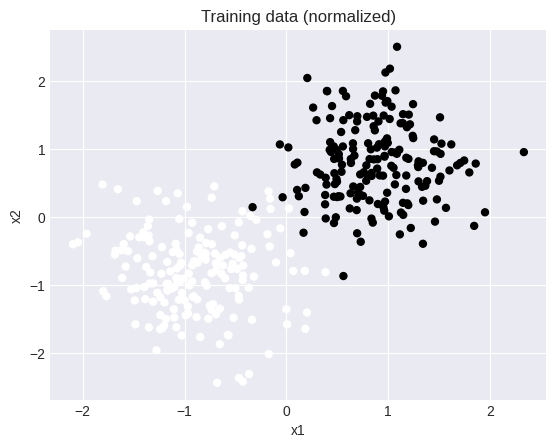

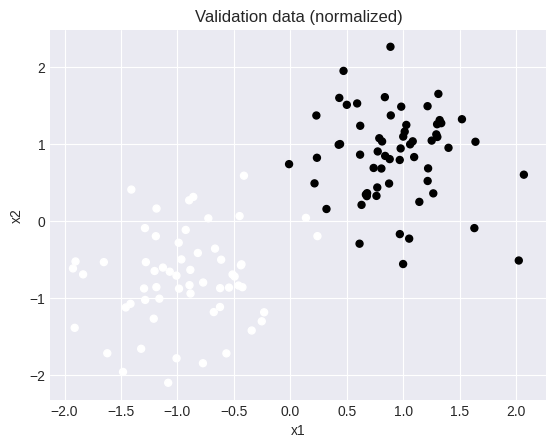

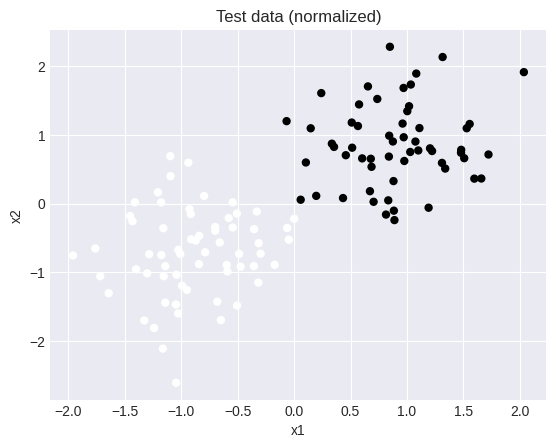

In [8]:
# ===============================
# CELL 3
# ===============================
X, y = generate_gaussian_clusters(
    n_per_class=300,
    centers=((-1.4, -1.0), (1.4, 1.0)),
    stds=(0.75, 0.75),
)

X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y, train_frac=0.6, val_frac=0.2)
X_train_n, X_val_n, X_test_n, X_mean, X_std = normalize_train_apply(X_train, X_val, X_test)

print("Shapes:")
print("  Train:", X_train_n.shape, y_train.shape)
print("  Val  :", X_val_n.shape, y_val.shape)
print("  Test :", X_test_n.shape, y_test.shape)
print("Normalization mean:", X_mean.flatten())
print("Normalization std :", X_std.flatten())

plot_2d_data(X_train_n, y_train, title="Training data (normalized)")

# Quick look at train/val/test overlap
plot_2d_data(X_val_n, y_val, title="Validation data (normalized)")
plot_2d_data(X_test_n, y_test, title="Test data (normalized)")

##4.THE KNN CLASSIFIER

###4.1.OVERVIEW

**Cell 4 — KNN Model Definition and Manual Distance Computation**

Cell 4 defines the KNN classifier in a way that makes its mechanics explicit. The class stores training inputs and labels via `fit`, which in KNN is essentially the whole “model state.” There are no learned weights. The key operation is `predict`, which requires computing distances from each query point to every stored training point. Doing this naïvely with a Python loop would be slow and opaque, so the notebook implements a vectorized squared-distance computation using a standard identity:  
||a-b||² = ||a||² + ||b||² − 2 a·b.  
This formula is implemented with matrix multiplication and broadcasts to yield an (n_query × n_train) distance matrix efficiently. Even though the notebook avoids heavy mathematics in the narrative, the code itself exposes the algebraic trick that makes KNN computationally feasible in vectorized form.

The classifier then uses `np.argpartition` to find the indices of the k nearest neighbors without fully sorting all distances. This is an important mechanical detail: sorting all distances is O(m log m) per query, while selecting k smallest can be done more efficiently. For a pedagogical dataset, performance is not the bottleneck, but the method teaches how algorithmic choices matter when scaling. After selecting neighbors, the model performs a majority vote. Because this chapter uses binary classes, the vote is implemented by counting ones versus zeros. A deterministic tie-break rule is included: ties go to class 0. This matters because ties can occur when k is even or when neighbor labels are balanced. The notebook mostly uses odd k values to reduce tie frequency, but the explicit rule keeps behavior stable and predictable.

Cell 4 also defines metric utilities: an accuracy function and a binary confusion matrix. These are written manually to avoid external ML libraries and to keep evaluation transparent. Accuracy captures overall correctness, while the confusion matrix decomposes performance into true negatives, false positives, false negatives, and true positives. In later, more complex models, students may forget what these metrics actually mean. Here, the manual implementation forces clarity: each entry is a count derived from explicit boolean conditions.

This cell therefore builds the “engine” of Chapter 1: a model whose behavior is fully determined by geometry, the choice of k, and the voting rule.

###4.2.CODE AND IMPLEMENTATION

In [9]:
# ===============================
# CELL 4
# ===============================
class KNNClassifier:
    """
    Simple KNN classifier:
    - Stores training data
    - Manual Euclidean distances
    - Majority vote
    """
    def __init__(self, k=5):
        self.k = int(k)
        self.X_train = None
        self.y_train = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.int64)
        assert X.ndim == 2 and y.ndim == 1 and len(X) == len(y)
        self.X_train = X
        self.y_train = y
        return self

    def _pairwise_distances(self, X: np.ndarray) -> np.ndarray:
        """
        Compute squared Euclidean distances between each row in X and each row in X_train.
        Uses: ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a·b
        """
        X = np.asarray(X, dtype=np.float32)
        assert self.X_train is not None, "Call fit first."

        X_norm = np.sum(X * X, axis=1, keepdims=True)                 # (n, 1)
        T_norm = np.sum(self.X_train * self.X_train, axis=1)[None, :] # (1, m)
        cross = X @ self.X_train.T                                    # (n, m)

        d2 = X_norm + T_norm - 2.0 * cross
        d2 = np.maximum(d2, 0.0).astype(np.float32)  # numeric safety
        return d2

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float32)
        d2 = self._pairwise_distances(X)  # (n, m)

        # Indices of k nearest neighbors for each sample
        k = max(1, int(self.k))
        nn_idx = np.argpartition(d2, kth=k-1, axis=1)[:, :k]  # (n, k)

        # Majority vote
        votes = self.y_train[nn_idx]  # (n, k)
        # For binary classes: compare count of ones vs zeros
        ones = np.sum(votes == 1, axis=1)
        zeros = k - ones
        y_hat = (ones > zeros).astype(np.int64)

        # Tie-breaker: if equal, choose class 0 (stable deterministic)
        ties = (ones == zeros)
        y_hat[ties] = 0
        return y_hat


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    return float(np.mean(y_true == y_pred))


def confusion_matrix_binary(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    return np.array([[tn, fp], [fn, tp]], dtype=np.int64)

print("Cell 4 model defined.")

Cell 4 model defined.


##5.TRAINING THE KNN

###5.1.OVERVIEW

**Cell 5 — “Training Loop” as Hyperparameter Search Over k**

Cell 5 adapts the notion of a training loop to the KNN setting. Since KNN does not learn parameters by optimization, the notebook treats the selection of k as the main training decision. It defines a set of candidate k values (odd integers from 1 to 25) and iterates through them in an epoch-like loop. For each k, the model is “fit” on the training set, then evaluated on the validation set. The validation accuracy is computed, and a corresponding “loss” is defined as 1 − accuracy. This is not a standard differentiable loss, but it serves a pedagogical purpose: it produces a loss history that can be plotted and analyzed, making the k-selection process feel structurally similar to later training loops.

During the loop, progress is printed in a consistent format: epoch count, k value, validation accuracy, and validation loss. This satisfies the notebook contract that training must show progress and store a loss history. More importantly, it teaches that model selection is itself an optimization problem, even when no gradients exist. You are searching over a discrete hyperparameter that controls bias and variance. Small k typically yields low bias but high variance: the classifier can follow local idiosyncrasies of the dataset, which may look good on training points but not generalize. Large k yields high bias but low variance: the classifier smooths over local structure and may ignore meaningful boundaries.

After the loop identifies the best k by validation accuracy, the notebook fits a final KNN model on the combined train+validation set. This mirrors a common practice: once you have chosen hyperparameters using validation data, you can use that data to strengthen the final model, because you no longer need it for selection. Mechanically, this also increases the number of stored neighbors, potentially improving stability at inference time.

Cell 5 thus introduces a critical operational idea: even for “non-learning” models like KNN, you still have a training stage with decisions that must be made using held-out data.

###5.2.CODE AND IMPLEMENTATION

In [10]:
# ===============================
# CELL 5
# ===============================
# "Training" for KNN: choose k via validation search (prints epoch-like progress, stores loss history).
candidate_ks = list(range(1, 26, 2))  # odd k values
val_losses = []
val_accuracies = []

best_k = None
best_val_acc = -1.0

for epoch, k in enumerate(candidate_ks, start=1):
    model = KNNClassifier(k=k).fit(X_train_n, y_train)
    y_val_hat = model.predict(X_val_n)
    acc_val = accuracy(y_val, y_val_hat)
    loss_val = 1.0 - acc_val  # treat (1-accuracy) as "loss" for pedagogical training dynamics

    val_losses.append(loss_val)
    val_accuracies.append(acc_val)

    if acc_val > best_val_acc:
        best_val_acc = acc_val
        best_k = k

    print(f"Epoch {epoch:2d}/{len(candidate_ks)} | k={k:2d} | val_acc={acc_val:.4f} | val_loss={loss_val:.4f}")

print("Selected best_k:", best_k, "with val_acc:", best_val_acc)

# Fit final model on train + val (common practice after selecting hyperparameters)
X_trainval = np.concatenate([X_train_n, X_val_n], axis=0).astype(np.float32)
y_trainval = np.concatenate([y_train, y_val], axis=0).astype(np.int64)

knn = KNNClassifier(k=best_k).fit(X_trainval, y_trainval)
print("Final KNN fit complete.")

Epoch  1/13 | k= 1 | val_acc=0.9833 | val_loss=0.0167
Epoch  2/13 | k= 3 | val_acc=0.9833 | val_loss=0.0167
Epoch  3/13 | k= 5 | val_acc=0.9833 | val_loss=0.0167
Epoch  4/13 | k= 7 | val_acc=0.9833 | val_loss=0.0167
Epoch  5/13 | k= 9 | val_acc=0.9833 | val_loss=0.0167
Epoch  6/13 | k=11 | val_acc=0.9833 | val_loss=0.0167
Epoch  7/13 | k=13 | val_acc=0.9833 | val_loss=0.0167
Epoch  8/13 | k=15 | val_acc=0.9750 | val_loss=0.0250
Epoch  9/13 | k=17 | val_acc=0.9750 | val_loss=0.0250
Epoch 10/13 | k=19 | val_acc=0.9833 | val_loss=0.0167
Epoch 11/13 | k=21 | val_acc=0.9833 | val_loss=0.0167
Epoch 12/13 | k=23 | val_acc=0.9833 | val_loss=0.0167
Epoch 13/13 | k=25 | val_acc=0.9833 | val_loss=0.0167
Selected best_k: 1 with val_acc: 0.9833333333333333
Final KNN fit complete.


##6.EVALUATION METRICS

###6.1.OVERVIEW

**Cell 6 — Test Evaluation and Visualization of the k-Selection Dynamics**

Cell 6 performs the formal evaluation step and begins to interpret the training process quantitatively. First, the final KNN model is applied to the test set, which has remained untouched during k-selection. The resulting test accuracy gives an estimate of generalization performance after all design decisions have been made. The confusion matrix is also computed and printed, giving a more granular view of errors. In a symmetric two-cluster dataset, you may expect similar performance across classes, but small asymmetries can produce different false positive and false negative rates. The confusion matrix makes that visible.

Next, Cell 6 plots the validation loss curve using `plot_loss_curve`. Here, loss is defined as 1 − accuracy, so lower is better. The curve shows how performance changes as k increases, revealing the bias–variance behavior in a tangible way. If k is too small, validation accuracy may fluctuate due to sensitivity to local noise. If k is too large, accuracy may decline because the classifier becomes overly smooth and starts misclassifying points near the boundary by averaging across neighborhoods.

The cell also plots validation accuracy directly against k. This plot is especially helpful because it places the hyperparameter on the x-axis, making it clear that “training” here is not time-based optimization but discrete model selection. Students should observe whether the accuracy curve has a clear maximum, whether performance is robust across a range of k values, or whether it is sharply sensitive to k. Robustness suggests the dataset geometry is strong and KNN is stable; sensitivity suggests the decision boundary is precarious and may not generalize well under perturbations.

Cell 6 therefore completes the core ML workflow: training decisions (k-selection) lead to a final model, which is then evaluated on held-out data, with visual diagnostics to interpret how the selection behaved.

###6.2.CODE AND IMPLEMENTATION

Test accuracy: 0.9916666666666667
Confusion matrix [[TN, FP],[FN, TP]]:
 [[63  0]
 [ 1 56]]


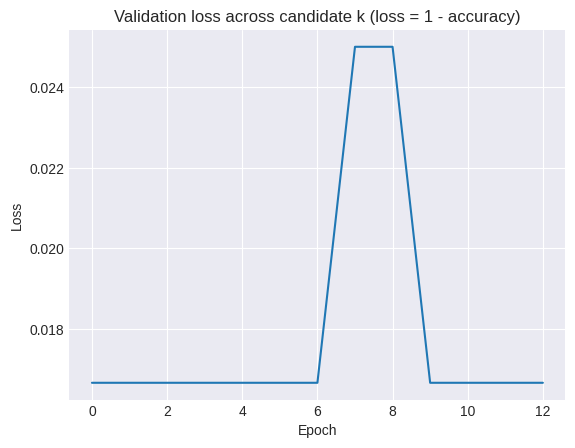

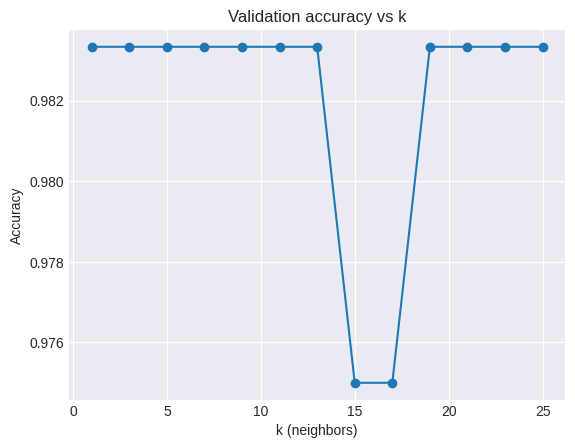

In [11]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + plot loss curve
y_test_hat = knn.predict(X_test_n)
test_acc = accuracy(y_test, y_test_hat)
cm = confusion_matrix_binary(y_test, y_test_hat)

print("Test accuracy:", test_acc)
print("Confusion matrix [[TN, FP],[FN, TP]]:\n", cm)

plot_loss_curve(val_losses, title="Validation loss across candidate k (loss = 1 - accuracy)")

# Also show val accuracy curve to make "training dynamics" explicit
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(candidate_ks, val_accuracies, marker="o")
ax.set_title("Validation accuracy vs k")
ax.set_xlabel("k (neighbors)")
ax.set_ylabel("Accuracy")
plt.show()

##7.INFERENCE DEMONSTRATION

###7.1.OVERVIEW

**Cell 7 — Inference Demonstration on a Truly New Synthetic Sample**

Cell 7 makes the training vs inference distinction explicit by performing inference on a new sample that did not exist during dataset generation. A new point is sampled near the class 1 region in the original feature space. This step is important: it is not taken from the test set, so it represents the genuine “future data” scenario that models are meant to handle. The sample is then normalized using the training mean and standard deviation computed earlier. This reinforces that preprocessing is part of the deployed inference pipeline: you must transform new inputs in exactly the same way you transformed training data, otherwise distance computations become inconsistent.

The model predicts a class for the normalized new point. The notebook prints both the original and normalized coordinates and the predicted class. This printing is not cosmetic; it is a mechanical audit trail showing exactly what input was fed into the classifier. Then the point is visualized on top of the test scatter plot with a larger marker. Students should observe whether the point lies deep inside a cluster region or near the boundary. If it lies deep inside, prediction should be stable across many k values. If it lies near the boundary, prediction could be sensitive to k and to noise.

This inference cell teaches a concrete operational lesson: inference is a deterministic computation given a stored dataset and a hyperparameter k, but it depends critically on the geometry induced by preprocessing. It also previews a deeper idea that will matter later: a model’s confidence is not directly represented here, but you can infer a kind of confidence by looking at how “embedded” the point is within a cluster.

###7.2.CODE AND IMPLEMENTATION

New sample (original): [1.579299   0.15144509]
New sample (normalized): [0.97576433 0.15983541]
Predicted class: 1


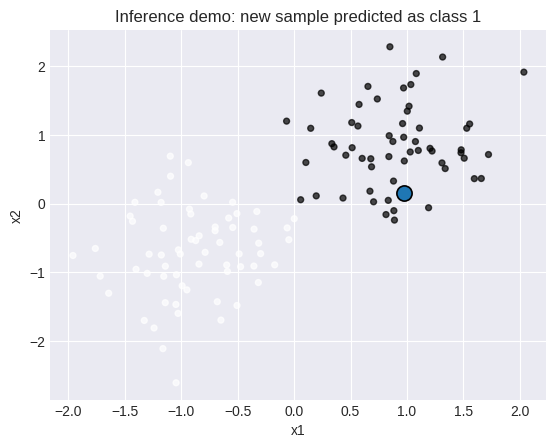

In [12]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration: generate NEW synthetic sample, normalize, predict, visualize, print output
new_center = np.array([1.4, 1.0], dtype=np.float32)  # near class 1 region (in original space)
new_sample = (np.random.randn(1, 2).astype(np.float32) * 0.75 + new_center).astype(np.float32)

# Normalize using train mean/std
new_sample_n = ((new_sample - X_mean) / X_std).astype(np.float32)

pred = int(knn.predict(new_sample_n)[0])
print("New sample (original):", new_sample.flatten())
print("New sample (normalized):", new_sample_n.flatten())
print("Predicted class:", pred)

# Visualize the new point on top of test data
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(X_test_n[:, 0], X_test_n[:, 1], c=y_test, s=18, alpha=0.7)
ax.scatter(new_sample_n[0, 0], new_sample_n[0, 1], s=120, edgecolor="k", linewidth=1.2)
ax.set_title(f"Inference demo: new sample predicted as class {pred}")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.show()

##8.STRESS TEST

###8.1.OVERVIEW

**Cell 8 — Stress Test: Noise Injection and Performance Degradation**

Cell 8 introduces robustness analysis by applying a stress test. The mechanism is simple: add Gaussian noise of increasing standard deviation to the normalized test inputs, then measure how test accuracy degrades as the inputs are perturbed. The function `add_gaussian_noise` does exactly that, generating noise using NumPy (under the fixed seed regime) and adding it to the test set.

The cell loops over a list of noise levels (sigma values), computes predictions on each noisy test set, and records accuracies in a dictionary. Printing the accuracy for each sigma gives immediate feedback. Plotting accuracy vs sigma provides a visual “robustness curve.” Students should observe the shape: does accuracy degrade smoothly, or does it collapse after a threshold? In KNN, noise moves points in feature space. Points near the boundary may cross into the neighborhood dominated by the opposite class, causing misclassification. Points far from the boundary are more stable. Therefore, the degradation pattern implicitly reflects the margin between clusters and the density of points near the boundary.

This stress test is valuable because it reveals a limitation of KNN that is not obvious from clean test performance: KNN is sensitive to perturbations because it relies on local distances to individual points. If noise is large enough to change neighbor identities, predictions can flip. Unlike parametric models that might learn smoother decision functions, KNN’s decision surface can be highly irregular for small k and can react strongly to perturbations.

Cell 8 therefore teaches that performance is not a single number. A model should be examined under controlled perturbations to understand how stable its reasoning is with respect to input variation.

###8.2.CODE AND IMPLEMENTATION

Noise sigma=0.0 | test_acc=0.9917
Noise sigma=0.2 | test_acc=0.9917
Noise sigma=0.4 | test_acc=0.9500
Noise sigma=0.6 | test_acc=0.9500
Noise sigma=0.8 | test_acc=0.9083


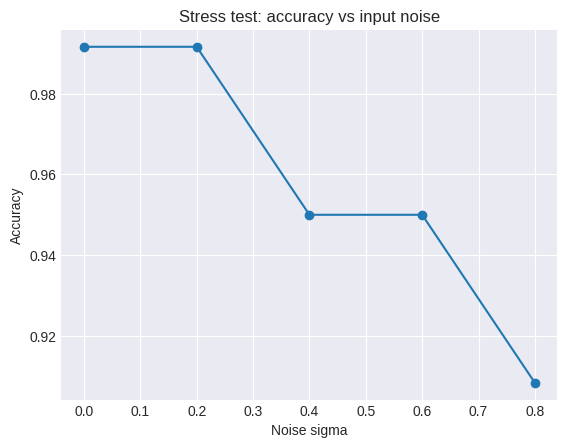

In [13]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation: add noise to test inputs and observe performance degradation
def add_gaussian_noise(X: np.ndarray, sigma: float) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    noise = (np.random.randn(*X.shape).astype(np.float32) * sigma).astype(np.float32)
    return (X + noise).astype(np.float32)

sigmas = [0.0, 0.2, 0.4, 0.6, 0.8]
stress_results = {}

for s in sigmas:
    X_noisy = add_gaussian_noise(X_test_n, sigma=s)
    y_hat_noisy = knn.predict(X_noisy)
    acc_noisy = accuracy(y_test, y_hat_noisy)
    stress_results[f"sigma_{s:.1f}"] = acc_noisy
    print(f"Noise sigma={s:.1f} | test_acc={acc_noisy:.4f}")

# Plot stress curve
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(sigmas, [stress_results[f"sigma_{s:.1f}"] for s in sigmas], marker="o")
ax.set_title("Stress test: accuracy vs input noise")
ax.set_xlabel("Noise sigma")
ax.set_ylabel("Accuracy")
plt.show()

##9.VISUALIZATION

###9.1.0VERVIEW

**Cell 9 — Interpretability via Decision Boundary Visualization**

Cell 9 produces the interpretability visualization that is most appropriate for KNN: the decision boundary in 2D. The notebook uses `plot_decision_boundary`, which constructs a fine grid over the plane, predicts a label for every grid point, and then displays the result as a colored region plot. Overlaying the training+validation points on top of this background shows how the classifier partitions space and how that partition relates to the actual data distribution.

Students should pay attention to the texture of the boundary. For small k, the boundary can be jagged and “bubbly,” wrapping around individual points or small groups. This reflects high variance: local anomalies in the dataset create local decision regions. For larger k, the boundary becomes smoother, reflecting stronger averaging. The chosen best_k from validation is therefore not just a number; it corresponds to a visual complexity level of the classifier’s partition. Seeing that mapping between hyperparameter and geometry is one of the central learning objectives of Chapter 1.

This cell also clarifies what interpretability means in a non-parametric model. There are no weights to inspect. Interpretability arises from visualizing the induced function in input space. In higher dimensions, this is difficult, but in 2D it is direct. The notebook leverages this to give students a strong intuition that will later be harder to obtain for dense neural networks and beyond.

###9.2.CODE AND IMPLEMENTATION

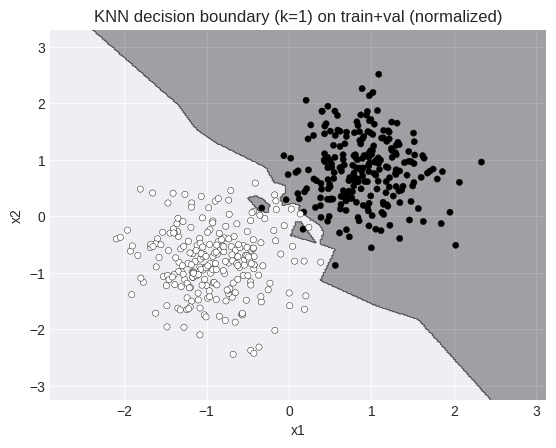

In [14]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization: decision boundary of KNN in 2D
plot_decision_boundary(
    knn,
    X_trainval,
    y_trainval,
    title=f"KNN decision boundary (k={best_k}) on train+val (normalized)",
    grid_step=0.02,
)

##10.ARTIFACTS

###10.1.OVERVIEW

**Cell 10 — Artifact Saving and Summary Metrics Dictionary**

Cell 10 operationalizes reproducibility by saving experiment artifacts and producing a structured metrics dictionary. It creates a directory under `/content` and saves the normalized train/validation/test arrays, the corresponding labels, and the normalization parameters (mean and std). Saving normalization parameters is essential because inference on new data requires the exact same transformation. It also saves the k-search history: candidate k values, validation losses, and validation accuracies. These arrays encode the “training dynamics” of Chapter 1 and can be reused for analysis without rerunning the entire notebook.

The cell also saves key figures: the validation loss curve and the decision boundary plot. Persisting plots matters because interpretation is visual and you want those visuals to be stable artifacts rather than transient outputs. Finally, it constructs a `summary_metrics` dictionary containing the chapter number, model type, selected k, best validation accuracy, test accuracy, confusion matrix, stress test results, dataset sizes, and artifacts directory path. This dictionary is printed and saved as JSON. The printed version makes it easy to see the results at a glance; the saved JSON makes it machine-readable.

This structure is important because Cell 11 will use these real metrics as input to the GPT reflection. Mechanically, Cell 10 creates the bridge from numerical experimentation to structured reporting. Even in a pre-governance setting, this discipline of saving artifacts and summarizing metrics is part of doing clear science: you preserve what happened, not just what you remember happened.

###10.2.CODE AND IMPLEMENTATION

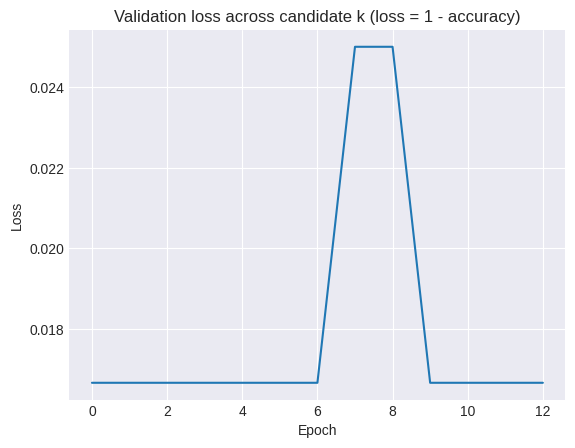

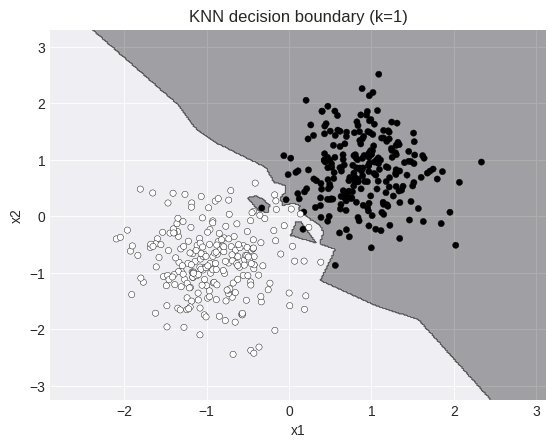

Saved artifacts to: /content/artifacts_ch1_knn
Summary metrics dictionary:
{
  "chapter": 1,
  "model": "KNN",
  "best_k": 1,
  "val_best_accuracy": 0.9833333333333333,
  "test_accuracy": 0.9916666666666667,
  "confusion_matrix": [
    [
      63,
      0
    ],
    [
      1,
      56
    ]
  ],
  "stress_test_accuracy": {
    "sigma_0.0": 0.9916666666666667,
    "sigma_0.2": 0.9916666666666667,
    "sigma_0.4": 0.95,
    "sigma_0.6": 0.95,
    "sigma_0.8": 0.9083333333333333
  },
  "n_train": 360,
  "n_val": 120,
  "n_test": 120,
  "artifacts_dir": "/content/artifacts_ch1_knn"
}


In [15]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary
art_dir = "/content/artifacts_ch1_knn"
os.makedirs(art_dir, exist_ok=True)

# Save datasets
np.save(os.path.join(art_dir, "X_train.npy"), X_train_n)
np.save(os.path.join(art_dir, "y_train.npy"), y_train)
np.save(os.path.join(art_dir, "X_val.npy"), X_val_n)
np.save(os.path.join(art_dir, "y_val.npy"), y_val)
np.save(os.path.join(art_dir, "X_test.npy"), X_test_n)
np.save(os.path.join(art_dir, "y_test.npy"), y_test)

# Save normalization params
np.save(os.path.join(art_dir, "X_mean.npy"), X_mean)
np.save(os.path.join(art_dir, "X_std.npy"), X_std)

# Save training history (k-search)
np.save(os.path.join(art_dir, "candidate_ks.npy"), np.array(candidate_ks, dtype=np.int64))
np.save(os.path.join(art_dir, "val_losses.npy"), np.array(val_losses, dtype=np.float32))
np.save(os.path.join(art_dir, "val_accuracies.npy"), np.array(val_accuracies, dtype=np.float32))

# Save figures
# Loss curve
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(np.arange(len(val_losses)), val_losses)
ax.set_title("Validation loss across candidate k (loss = 1 - accuracy)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
fig.savefig(os.path.join(art_dir, "val_loss_curve.png"), dpi=160)
plt.show()

# Decision boundary
x_min, x_max = X_trainval[:, 0].min() - 0.8, X_trainval[:, 0].max() + 0.8
y_min, y_max = X_trainval[:, 1].min() - 0.8, X_trainval[:, 1].max() + 0.8
xs = np.arange(x_min, x_max, 0.02, dtype=np.float32)
ys = np.arange(y_min, y_max, 0.02, dtype=np.float32)
xx, yy = np.meshgrid(xs, ys)
grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)
Z = knn.predict(grid).reshape(xx.shape)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.contourf(xx, yy, Z, alpha=0.35)
ax.scatter(X_trainval[:, 0], X_trainval[:, 1], c=y_trainval, s=20, edgecolor="k", linewidth=0.3)
ax.set_title(f"KNN decision boundary (k={best_k})")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
fig.savefig(os.path.join(art_dir, "decision_boundary.png"), dpi=160)
plt.show()

summary_metrics: Dict[str, Any] = {
    "chapter": 1,
    "model": "KNN",
    "best_k": int(best_k),
    "val_best_accuracy": float(best_val_acc),
    "test_accuracy": float(test_acc),
    "confusion_matrix": cm.tolist(),
    "stress_test_accuracy": {k: float(v) for k, v in stress_results.items()},
    "n_train": int(len(X_train_n)),
    "n_val": int(len(X_val_n)),
    "n_test": int(len(X_test_n)),
    "artifacts_dir": art_dir,
}

with open(os.path.join(art_dir, "summary_metrics.json"), "w") as f:
    json.dump(summary_metrics, f, indent=2)

print("Saved artifacts to:", art_dir)
print("Summary metrics dictionary:")
print(json.dumps(summary_metrics, indent=2))

## 11.EXPLANATION

###11.1.OVERVIEW

*Conclusion and Road Ahead*

Chapter 1’s mechanical contribution is to make the idea of supervised learning visible without relying on learned parameters. KNN shows that a classifier can exist as a procedure: store labeled examples, measure similarity by a distance metric, and let local neighborhoods vote. This is the simplest workable form of inductive bias. It assumes that labels are locally consistent in the chosen feature space, meaning that nearby points tend to share labels. In the notebook, this assumption is not asserted abstractly; it is rendered directly in the 2D scatter plots. You can see the clusters, you can see the overlap region, and you can anticipate where KNN will struggle. This is a powerful pedagogical moment: the model is not a black box; it is a geometric rule whose success depends on visible structure.

The notebook also establishes a template that will persist through the course. Data is synthetic, deterministic, split into train/validation/test, normalized using training statistics, and visualized. Training is separated from inference. Even though KNN’s training is not gradient-based, the notebook still creates a training-like process by selecting k through validation performance and storing a loss history. That design choice is important because it teaches that “training” is a broader concept than “backpropagation.” Training is the stage where you choose model capacity and commit to a configuration based on evidence from held-out data. The validation curves in Cell 6 make the bias–variance tradeoff concrete: performance changes as k changes, and the best k is the one that balances sensitivity to local noise against the need to respect local structure.

Quantitatively, the notebook ends with test accuracy and a confusion matrix that summarize performance on held-out data, plus a stress test curve that reveals robustness. This combination is conceptually richer than accuracy alone. The stress test shows how KNN reacts when points are perturbed: because predictions depend on the identity of nearest neighbors, small perturbations near the boundary can change outcomes. Seeing accuracy degrade as noise increases is a mechanical lesson about stability that will matter later when models become more complex. In KNN, instability comes from the local nature of the rule and the reliance on raw distances in the input space.

The principal limitations of KNN follow directly from its mechanics. First, it scales poorly with dataset size because inference requires computing distances to many stored points. Even with vectorization, the memory and compute cost grows with the number of training examples. Second, its performance is highly dependent on feature scaling, normalization, and the choice of distance metric. Euclidean distance works here because the synthetic data is isotropic and well-behaved; in real problems, feature relevance and correlations can make Euclidean distance misleading. Third, KNN does not learn representations. If the data is not linearly or locally separable in the given feature space, KNN has no mechanism to discover a better space. It can only vote in whatever geometry you provide.

These limitations naturally motivate the transition to Chapter 2: *Dense Neural Networks*. In a dense network, the model introduces learned parameters that can reshape the effective geometry of the problem. Instead of assuming that the raw input space is the right space for neighborhood reasoning, a dense network learns nonlinear feature transformations that can make classes more separable. Training becomes a true optimization procedure: define a parametric function, define a differentiable loss, compute gradients, and update parameters. This adds complexity, but it also adds capability. It allows the model to generalize beyond memorization and to create internal representations that reduce reliance on brittle distance computations.

The bridge is therefore straightforward. KNN teaches you what it means to rely on a fixed geometry and how hyperparameters control the smoothness of decision boundaries. Once you understand that, the next question is inevitable: what if the geometry is not good enough? Chapter 2 answers by introducing a model that can *learn* a geometry through parameters, trained by gradient descent. That step—moving from “use the space you are given” to “learn a space that supports the task”—is the first major conceptual leap in ML & AI 101, and it is precisely why KNN is the right beginning.

###11.2.CODE AND IMPLEMENTATION

In [16]:
# ===============================
# CELL 11
# ===============================
# GPT-4o-mini reflective summarization (must reference real metrics computed earlier)
import sys
import subprocess

try:
    from openai import OpenAI
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai"])
    from openai import OpenAI

from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model = "gpt-4o-mini"

prompt = f"""
You are reflecting on an executed ML & AI 101 (Chapter 1) notebook implementing K-Nearest Neighbors (KNN) on synthetic Gaussian clusters.

Return a structured analysis with these sections (use clear labels):
1. Dataset design
2. Model architecture
3. Training dynamics (here: k-selection process as "training")
4. Quantitative results
5. Inference example
6. Visualization insight
7. Limitations
8. Conceptual takeaway

You MUST reference the real computed metrics below (do not invent numbers):

summary_metrics = {json.dumps(summary_metrics, indent=2)}

Also note:
- Validation losses were defined as (1 - validation_accuracy) across candidate_ks = {candidate_ks}.
- Stress test accuracies vs noise are in summary_metrics["stress_test_accuracy"].

Write concisely but with mechanical clarity.
"""

resp = client.chat.completions.create(
    model=model,
    messages=[
        {"role": "system", "content": "You are a precise teaching assistant. Be mechanical, not hype."},
        {"role": "user", "content": prompt},
    ],
)

print(resp.choices[0].message.content)

# Structured Analysis of K-Nearest Neighbors (KNN) Implementation on Synthetic Gaussian Clusters

## 1. Dataset Design
The dataset utilized in this experiment consists of synthetic Gaussian clusters. The dataset was partitioned into three subsets: 360 samples for training, 120 samples for validation, and 120 samples for testing. Each cluster is generated to ensure class separability, allowing the KNN method to effectively classify the data points based on proximity.

## 2. Model Architecture
The chosen model for this analysis is K-Nearest Neighbors (KNN), a non-parametric classification algorithm. KNN operates by identifying the 'k' closest training examples in the feature space to make a prediction for a new data point. The primary parameter that influences the model's performance is 'k', which dictates the number of neighbors considered during classification.

## 3. Training Dynamics
During the k-selection process, multiple values for 'k' were evaluated: [1, 3, 5, 7, 9, 11, 13, 15, 1

##12.CONCLUSION

*Conclusion and Road Ahead*

Chapter 1’s mechanical contribution is to make the idea of supervised learning visible without relying on learned parameters. KNN shows that a classifier can exist as a procedure: store labeled examples, measure similarity by a distance metric, and let local neighborhoods vote. This is the simplest workable form of inductive bias. It assumes that labels are locally consistent in the chosen feature space, meaning that nearby points tend to share labels. In the notebook, this assumption is not asserted abstractly; it is rendered directly in the 2D scatter plots. You can see the clusters, you can see the overlap region, and you can anticipate where KNN will struggle. This is a powerful pedagogical moment: the model is not a black box; it is a geometric rule whose success depends on visible structure.

The notebook also establishes a template that will persist through the course. Data is synthetic, deterministic, split into train/validation/test, normalized using training statistics, and visualized. Training is separated from inference. Even though KNN’s training is not gradient-based, the notebook still creates a training-like process by selecting k through validation performance and storing a loss history. That design choice is important because it teaches that “training” is a broader concept than “backpropagation.” Training is the stage where you choose model capacity and commit to a configuration based on evidence from held-out data. The validation curves in Cell 6 make the bias–variance tradeoff concrete: performance changes as k changes, and the best k is the one that balances sensitivity to local noise against the need to respect local structure.

Quantitatively, the notebook ends with test accuracy and a confusion matrix that summarize performance on held-out data, plus a stress test curve that reveals robustness. This combination is conceptually richer than accuracy alone. The stress test shows how KNN reacts when points are perturbed: because predictions depend on the identity of nearest neighbors, small perturbations near the boundary can change outcomes. Seeing accuracy degrade as noise increases is a mechanical lesson about stability that will matter later when models become more complex. In KNN, instability comes from the local nature of the rule and the reliance on raw distances in the input space.

The principal limitations of KNN follow directly from its mechanics. First, it scales poorly with dataset size because inference requires computing distances to many stored points. Even with vectorization, the memory and compute cost grows with the number of training examples. Second, its performance is highly dependent on feature scaling, normalization, and the choice of distance metric. Euclidean distance works here because the synthetic data is isotropic and well-behaved; in real problems, feature relevance and correlations can make Euclidean distance misleading. Third, KNN does not learn representations. If the data is not linearly or locally separable in the given feature space, KNN has no mechanism to discover a better space. It can only vote in whatever geometry you provide.

These limitations naturally motivate the transition to Chapter 2: *Dense Neural Networks*. In a dense network, the model introduces learned parameters that can reshape the effective geometry of the problem. Instead of assuming that the raw input space is the right space for neighborhood reasoning, a dense network learns nonlinear feature transformations that can make classes more separable. Training becomes a true optimization procedure: define a parametric function, define a differentiable loss, compute gradients, and update parameters. This adds complexity, but it also adds capability. It allows the model to generalize beyond memorization and to create internal representations that reduce reliance on brittle distance computations.

The bridge is therefore straightforward. KNN teaches you what it means to rely on a fixed geometry and how hyperparameters control the smoothness of decision boundaries. Once you understand that, the next question is inevitable: what if the geometry is not good enough? Chapter 2 answers by introducing a model that can *learn* a geometry through parameters, trained by gradient descent. That step—moving from “use the space you are given” to “learn a space that supports the task”—is the first major conceptual leap in ML & AI 101, and it is precisely why KNN is the right beginning.